# Evolutionary Multi-Objective Portfolio Optimisation

This notebook demonstrates the **evoport** framework for portfolio construction via
evolutionary multi-objective optimisation. We evolve a population of portfolio weight
vectors over several generations, using domination-based selection to push the
population toward the Pareto frontier in risk--return space.

**Objectives optimised:** Annualised Sharpe Ratio (maximise) and CVaR at 5 % (maximise / less negative is better).

**Key concepts:**
- *Population sampling* under long-only budget constraints
- *Epsilon-dominance* selection for frontier sparsification
- *Breeding* via Gaussian perturbation with projection back to the feasible set

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

from utils.enums.data import Data
from utils.loss.template import ListLoss
from utils.loss.mean_ret import MeanRet
from utils.loss.sharpe import Sharpe
from utils.loss.cvar import CVaR
from utils.loss.win_loss import WinLoss
from utils.loss.max_dd import MaxDD
from utils.populations.implementations import LongOnlyBC, LongOnlyBR
from utils.domination import pareto, epsilon
from utils.evolution import Evolution
from utils.backtest import Backtest

# ---------------------------------------------------------------------------
# Global plot style — clean, publication-ready
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

PALETTE = sns.color_palette('colorblind')
IMG_DIR = '../images'

np.random.seed(42)

## 1. Data Loading

We load daily price data for 5 assets and compute simple returns.

In [29]:
prices = pd.read_csv('../data/prices.csv', index_col='date').iloc[0:800]
returns = prices.pct_change().dropna().values
mean_ret = returns.mean(axis=0)

data_package = {
    Data.MeanRet: mean_ret,
    Data.Returns: returns,
}

n_assets = returns.shape[1]
print(f'Assets:  {prices.columns.tolist()}')
print(f'Returns: {returns.shape[0]} days × {n_assets} assets')

Assets:  ['ASSET_0', 'ASSET_1', 'ASSET_2', 'ASSET_3', 'ASSET_4', 'ASSET_5', 'ASSET_6', 'ASSET_7', 'ASSET_8', 'ASSET_9', 'ASSET_10', 'ASSET_11', 'ASSET_12', 'ASSET_13', 'ASSET_14', 'ASSET_15', 'ASSET_16', 'ASSET_17', 'ASSET_18', 'ASSET_19', 'ASSET_20', 'ASSET_21', 'ASSET_22', 'ASSET_23', 'ASSET_24', 'ASSET_25', 'ASSET_26', 'ASSET_27', 'ASSET_28', 'ASSET_29', 'ASSET_30', 'ASSET_31', 'ASSET_32', 'ASSET_33', 'ASSET_34', 'ASSET_35', 'ASSET_36', 'ASSET_37', 'ASSET_38', 'ASSET_39', 'ASSET_40', 'ASSET_41', 'ASSET_42', 'ASSET_43', 'ASSET_44', 'ASSET_45', 'ASSET_46', 'ASSET_47', 'ASSET_48', 'ASSET_49']
Returns: 799 days × 50 assets


## 2. Population Sampling

Two population types are compared:
- **LongOnlyBC** (Budget-Constrained): weights are non-negative and sum to exactly 1 (fully invested).
- **LongOnlyBR** (Budget-Relaxed): weights are non-negative and sum to *at most* 1 (partial cash allocation allowed).

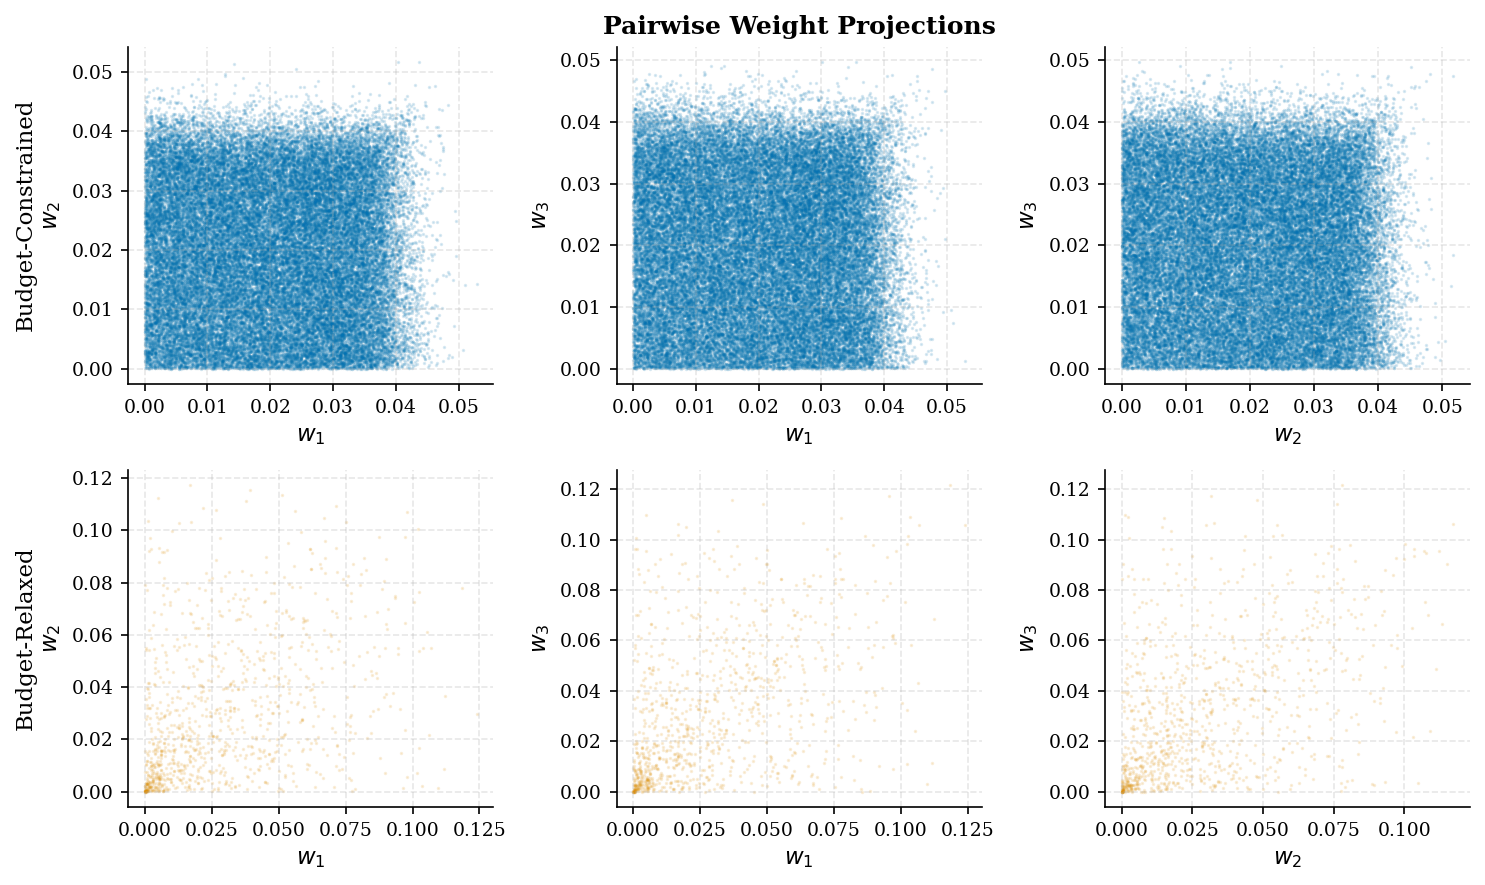

In [56]:
POP_SIZE = 50_000

population_lobc = LongOnlyBC(problem_dimension=n_assets, population_size=POP_SIZE)
population_lobr = LongOnlyBR(problem_dimension=n_assets, budget_max=3)

# --- Figure 1: Weight-space comparison (pairwise projections) -------------
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=False, sharey=False)
pairs = [(0, 1), (0, 2), (1, 2)]
labels = [f'$w_{{{i+1}}}$' for i in range(n_assets)]

for col, (i, j) in enumerate(pairs):
    for row, (pop, title) in enumerate([
        (population_lobc, 'Budget-Constrained'),
        (population_lobr, 'Budget-Relaxed'),
    ]):
        ax = axes[row, col]
        ax.scatter(pop.initial_weights[:, i], pop.initial_weights[:, j],
                   s=0.4, alpha=0.15, color=PALETTE[row], rasterized=True)
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        if col == 0:
            ax.set_ylabel(f'{title}\n{labels[j]}')

axes[0, 1].set_title('Pairwise Weight Projections', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/weight_space.png', bbox_inches='tight')
plt.show()

## 3. Objective Evaluation & Initial Frontier

We evaluate every portfolio on two objectives — **Sharpe Ratio** and **CVaR (5 %)** — and
identify the non-dominated set using epsilon-dominance ($\varepsilon = 0.2$).

In [60]:
alpha=0.025
losses = [Sharpe('Sharpe Ratio'), CVaR(f'CVar{100 * alpha:.2f}%', alpha=alpha)]
list_loss = ListLoss(losses)
higher_is_better = [not m for m in list_loss.minimax_structure]

obj_x, obj_y = losses[0].name, losses[1].name

# Evaluate initial population
results_init = list_loss.evaluate(population_lobc.initial_weights, data_package)
df_init = pd.DataFrame(results_init)

# Epsilon-dominant frontier
df_front_init = epsilon.epsilon_dominant(
    df=df_init, cols=list(df_init.columns),
    higher_is_better=higher_is_better, epsilon=0.2,
)
front_idx_init = df_front_init.index

print(f'Population size:        {POP_SIZE:,}')
print(f'Frontier size (ε=0.2):  {len(front_idx_init):,}  '
      f'({100*len(front_idx_init)/POP_SIZE:.1f}%)')

Population size:        50,000
Frontier size (ε=0.2):  3,978  (8.0%)


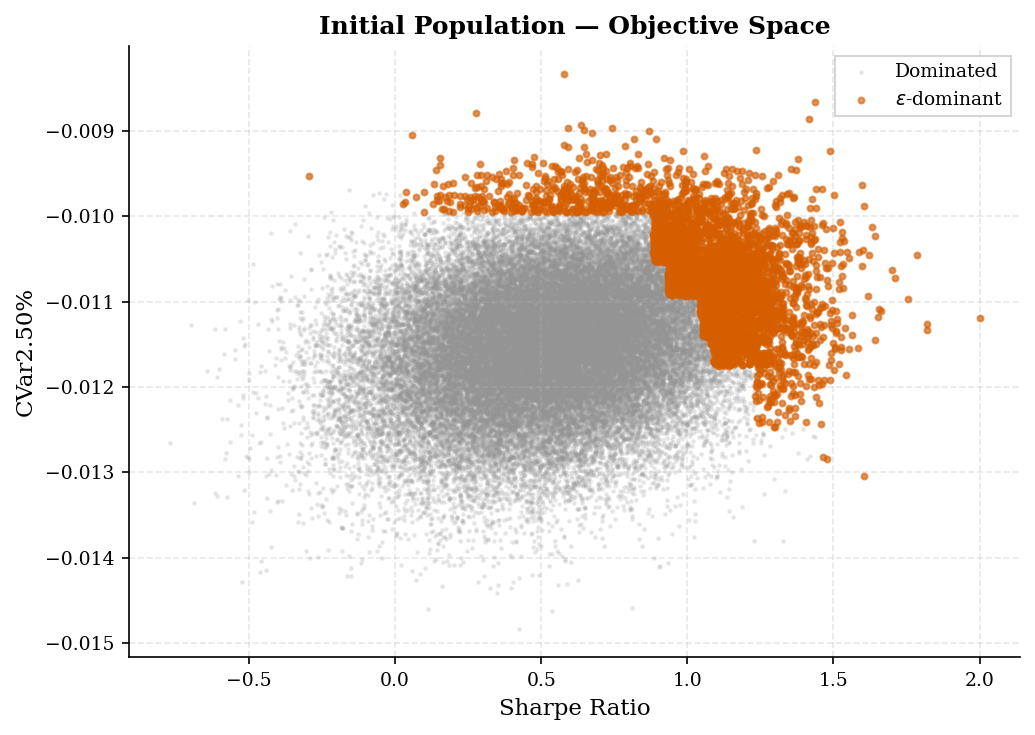

In [61]:
# --- Figure 2: Objective space with frontier highlighted ------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df_init[obj_x], df_init[obj_y],
           s=2, alpha=0.15, color=PALETTE[7], label='Dominated', rasterized=True)
ax.scatter(df_init[obj_x].iloc[front_idx_init],
           df_init[obj_y].iloc[front_idx_init],
           s=8, alpha=0.6, color=PALETTE[3], label=r'$\varepsilon$-dominant', zorder=3)

ax.set_xlabel(f'{obj_x}')
ax.set_ylabel(f'{obj_y}')
ax.set_title('Initial Population — Objective Space', fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/initial_frontier.png', bbox_inches='tight')
plt.show()

## 4. Evolutionary Loop

Each generation:
1. Evaluate all portfolios on both objectives.
2. Select the $\varepsilon$-dominant subset (survivors).
3. Breed new children by perturbing survivors and projecting back to the feasible set.
4. Repeat.

In [62]:
N_GENERATIONS = 201

evo = Evolution(
    population=population_lobc,
    list_loss=list_loss,
    domination_fn=epsilon.epsilon_dominant,
    domination_kwargs={'epsilon': 0.2},
)

result = evo.run(data_package, n_generations=N_GENERATIONS, verbose=True)

Gen  0  |  frontier:  3,978  |  Sharpe Ratio: 0.5456 | CVar2.50%: -0.0115
Gen  1  |  frontier:  9,542  |  Sharpe Ratio: 0.6292 | CVar2.50%: -0.0143
Gen  2  |  frontier: 16,552  |  Sharpe Ratio: 0.7334 | CVar2.50%: -0.0139
Gen  3  |  frontier: 20,634  |  Sharpe Ratio: 0.8259 | CVar2.50%: -0.0134
Gen  4  |  frontier: 24,399  |  Sharpe Ratio: 0.8587 | CVar2.50%: -0.0130
Gen  5  |  frontier: 28,745  |  Sharpe Ratio: 0.8907 | CVar2.50%: -0.0127
Gen  6  |  frontier: 23,711  |  Sharpe Ratio: 0.9060 | CVar2.50%: -0.0125
Gen  7  |  frontier: 19,472  |  Sharpe Ratio: 0.8660 | CVar2.50%: -0.0126
Gen  8  |  frontier: 23,260  |  Sharpe Ratio: 0.7850 | CVar2.50%: -0.0128
Gen  9  |  frontier: 26,528  |  Sharpe Ratio: 0.8083 | CVar2.50%: -0.0123
Gen 10  |  frontier: 29,187  |  Sharpe Ratio: 0.8356 | CVar2.50%: -0.0119
Gen 11  |  frontier: 30,514  |  Sharpe Ratio: 0.8506 | CVar2.50%: -0.0118
Gen 12  |  frontier: 29,491  |  Sharpe Ratio: 0.8688 | CVar2.50%: -0.0117
Gen 13  |  frontier: 32,366  |  Sharpe

## 5. Frontier Evolution

We visualise how the population shifts in objective space across generations, and track
convergence statistics.

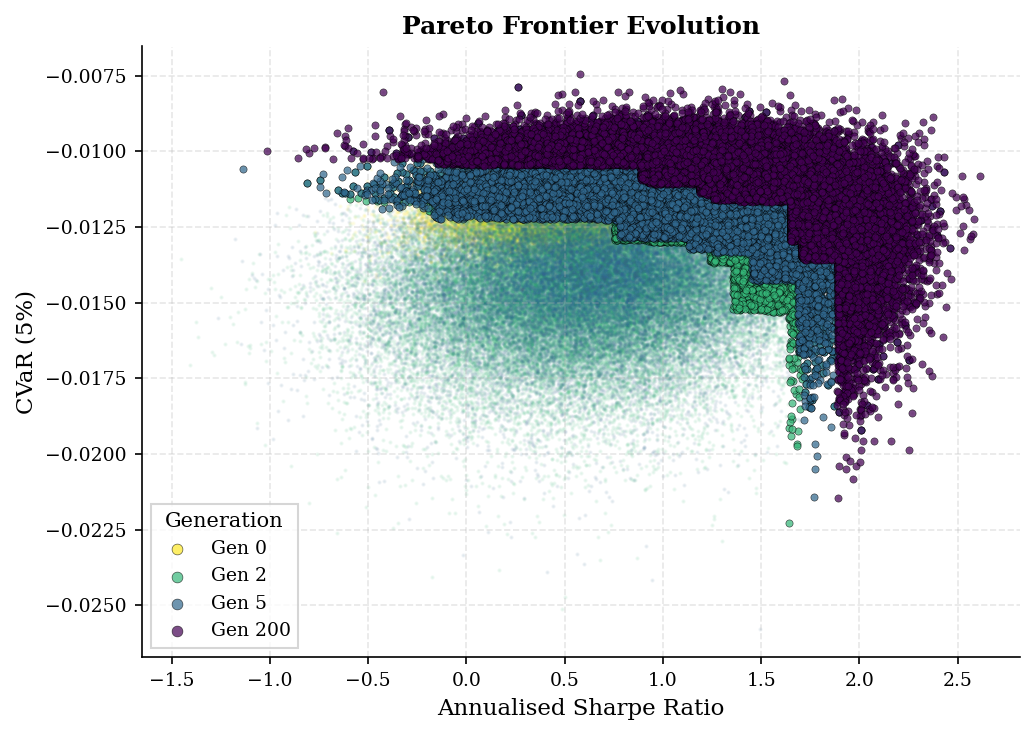

In [63]:
# --- Figure 3: Frontier evolution across selected generations -------------
history = result.history
show_gens = [0, 2, 5, N_GENERATIONS - 1]
cmap = plt.cm.viridis_r

fig, ax = plt.subplots(figsize=(7, 5))

for k, g in enumerate(show_gens):
    h = history[g]
    df_g = h['objectives']
    fidx = h['frontier_idx']
    colour = cmap(k / (len(show_gens) - 1))
    
    ax.scatter(df_g[obj_x], df_g[obj_y],
               s=1, alpha=0.08, color=colour, rasterized=True)
    ax.scatter(df_g[obj_x].iloc[fidx], df_g[obj_y].iloc[fidx],
               s=12, alpha=0.7, color=colour,
               edgecolors='k', linewidths=0.3,
               label=f'Gen {g}', zorder=4)

ax.set_xlabel('Annualised Sharpe Ratio')
ax.set_ylabel('CVaR (5%)')
ax.set_title('Pareto Frontier Evolution', fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8',
          markerscale=1.5, title='Generation')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/frontier_evolution.png', bbox_inches='tight')
plt.show()

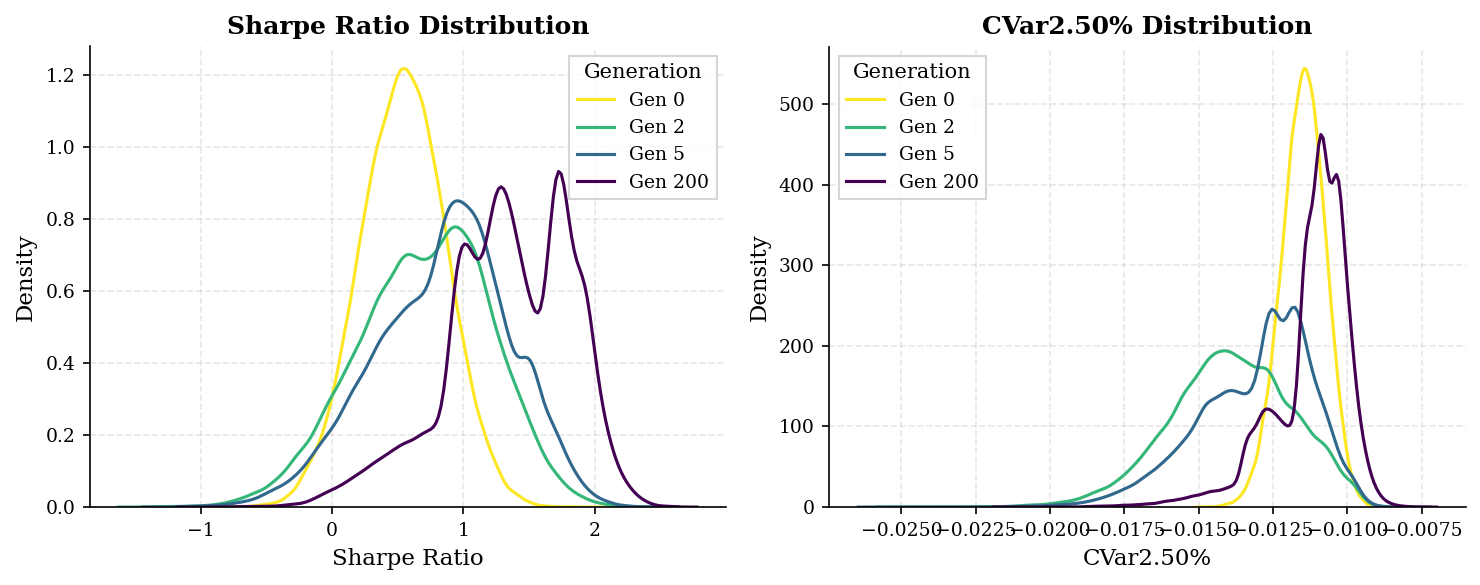

In [64]:
# --- Figure 4: Objective distribution shift (KDE) ------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, [obj_x, obj_y],
                            [obj_x, obj_y]):
    for g in show_gens:
        colour = cmap(show_gens.index(g) / (len(show_gens) - 1))
        vals = history[g]['objectives'][col].replace([np.inf, -np.inf], np.nan).dropna()
        sns.kdeplot(vals, ax=ax, color=colour, label=f'Gen {g}', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(frameon=True, fancybox=False, edgecolor='0.8', title='Generation')

axes[0].set_title(f'{obj_x} Distribution', fontweight='bold')
axes[1].set_title(f'{obj_y} Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/objective_distributions.png', bbox_inches='tight')
plt.show()

## 6. Convergence Diagnostics

We track the median and interquartile range of each objective across generations to
confirm the population is improving monotonically.

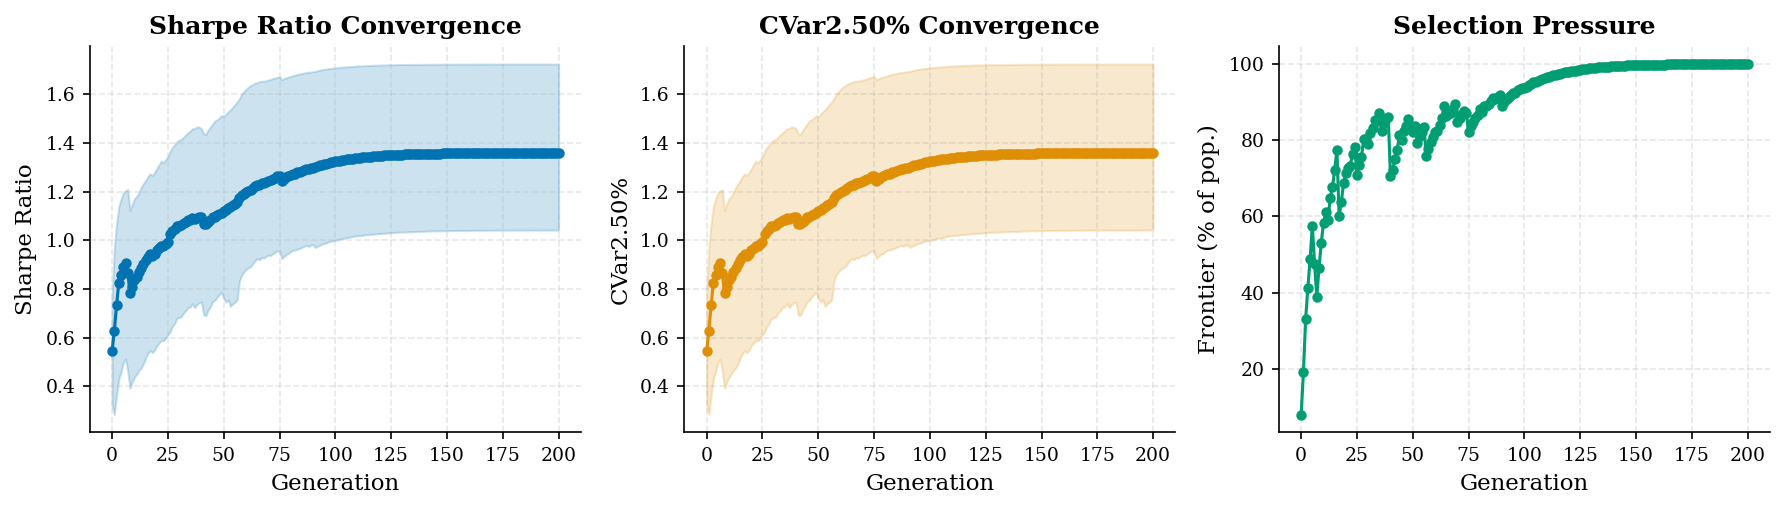

In [65]:
# --- Figure 5: Convergence curves ----------------------------------------
stats = pd.DataFrame([
    {
        'gen': h['gen'],
        f'{obj_x}_median': h['objectives'][obj_x].median(),
        f'{obj_x}_q25': h['objectives'][obj_x].quantile(0.25),
        f'{obj_x}_q75': h['objectives'][obj_x].quantile(0.75),
        f'{obj_y}_median': h['objectives'][obj_y].median(),
        f'{obj_y}_q25': h['objectives'][obj_y].quantile(0.25),
        f'{obj_y}_q75': h['objectives'][obj_y].quantile(0.75),
        'frontier_pct': 100 * h['frontier_size'] / POP_SIZE,
    }
    for h in history
])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Sharpe
ax = axes[0]
ax.fill_between(stats['gen'], stats[f'{obj_x}_q25'], stats[f'{obj_x}_q75'],
                alpha=0.2, color=PALETTE[0])
ax.plot(stats['gen'], stats[f'{obj_x}_median'], '-o', ms=4, color=PALETTE[0])
ax.set_xlabel('Generation')
ax.set_ylabel(f'{obj_x}')
ax.set_title(f'{obj_x} Convergence', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# CVaR
ax = axes[1]
ax.fill_between(stats['gen'], stats[f'{obj_x}_q25'], stats[f'{obj_x}_q75'],
                alpha=0.2, color=PALETTE[1])
ax.plot(stats['gen'], stats[f'{obj_x}_median'], '-o', ms=4, color=PALETTE[1])
ax.set_xlabel('Generation')
ax.set_ylabel(f'{obj_y}')
ax.set_title(f'{obj_y} Convergence', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Frontier fraction
ax = axes[2]
ax.plot(stats['gen'], stats['frontier_pct'], '-o', ms=4, color=PALETTE[2])
ax.set_xlabel('Generation')
ax.set_ylabel('Frontier (% of pop.)')
ax.set_title('Selection Pressure', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/convergence.png', bbox_inches='tight')
plt.show()

## 7. Final Frontier — Portfolio Analysis

We inspect the weight allocations of portfolios on the final Pareto frontier, sorted
by Sharpe ratio.

In [66]:
# Final frontier from Evolution result
asset_names = prices.columns.tolist()
frontier_df = pd.DataFrame(result.frontier_weights, columns=asset_names)
frontier_df[f'{obj_x}'] = result.frontier_objectives[obj_x].values
frontier_df[f'{obj_y}'] = result.frontier_objectives[obj_y].values
frontier_df = frontier_df.sort_values(f'{obj_x}', ascending=False).reset_index(drop=True)

print(f'Final frontier: {len(frontier_df):,} portfolios')
frontier_df.head(10).round(4)

Final frontier: 49,992 portfolios


,ASSET_0,ASSET_1,ASSET_2,ASSET_3,ASSET_4,ASSET_5,ASSET_6,ASSET_7,ASSET_8,ASSET_9,...,ASSET_42,ASSET_43,ASSET_44,ASSET_45,ASSET_46,ASSET_47,ASSET_48,ASSET_49,Sharpe Ratio,CVar2.50%
0,0.0168,0.0260,0.0383,0.0000,0.0000,0.0000,0.0000,0.0509,0.0768,0.0103,...,0.0000,0.0000,0.0060,0.0377,0.0230,0.0938,0.0469,0.0263,2.6137,-0.0108
1,0.0100,0.0263,0.0549,0.0108,0.0064,0.0051,0.0056,0.0272,0.0424,0.0010,...,0.0000,0.0000,0.0000,0.0814,0.0000,0.0000,0.0806,0.0140,2.5816,-0.0122
2,0.0000,0.0228,0.0555,0.0000,0.0344,0.0000,0.0029,0.0391,0.0000,0.0096,...,0.0089,0.0236,0.0191,0.0760,0.0290,0.0127,0.0429,0.0548,2.5769,-0.0127
3,0.0000,0.0000,0.0169,0.0020,0.0280,0.0000,0.0000,0.0395,0.0719,0.0040,...,0.0000,0.0636,0.0310,0.0884,0.0000,0.0201,0.0000,0.0146,2.5699,-0.0128
4,0.0188,0.0000,0.0443,0.0014,0.0067,0.0000,0.0000,0.0000,0.0406,0.0264,...,0.0000,0.0498,0.0194,0.0934,0.0000,0.0254,0.0371,0.0717,2.5615,-0.0129
5,0.0000,0.0528,0.0232,0.0000,0.0088,0.0000,0.0000,0.1266,0.0000,0.0000,...,0.0000,0.0393,0.0000,0.0513,0.0031,0.0087,0.0552,0.0000,2.5594,-0.0119
6,0.0251,0.0557,0.0389,0.0000,0.0054,0.0028,0.0249,0.1004,0.0897,0.0679,...,0.0000,0.0000,0.0000,0.0831,0.0000,0.0000,0.0000,0.0000,2.5405,-0.0118
7,0.0000,0.0079,0.0647,0.0000,0.0197,0.0000,0.0000,0.0714,0.0590,0.0056,...,0.0214,0.0480,0.0580,0.0431,0.0000,0.0000,0.0499,0.0318,2.5344,-0.0116
8,0.0000,0.0058,0.0882,0.0047,0.0000,0.0000,0.0000,0.0944,0.0504,0.0000,...,0.0000,0.0000,0.0000,0.1158,0.0000,0.0000,0.0075,0.0000,2.5341,-0.0133
9,0.0000,0.0375,0.0519,0.0000,0.0134,0.0000,0.0000,0.0536,0.0871,0.0000,...,0.0000,0.0000,0.0277,0.0650,0.0276,0.0249,0.0000,0.0000,2.5264,-0.0125


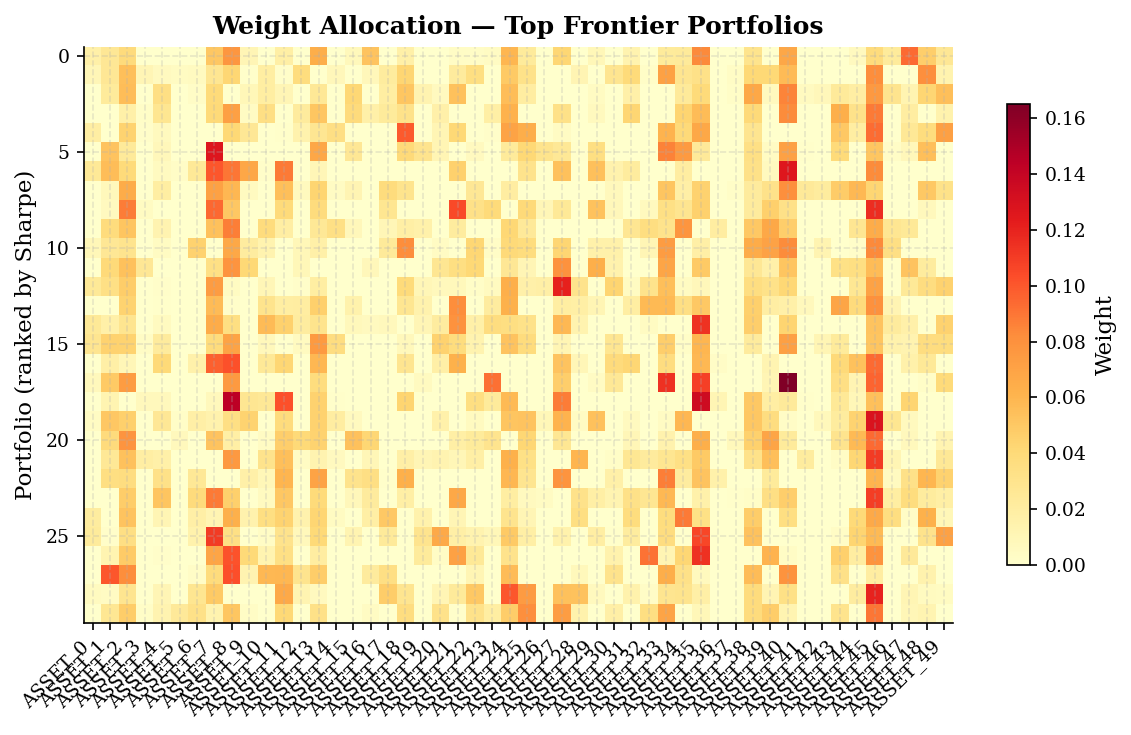

In [67]:
# --- Figure 6: Weight allocation heatmap for top frontier portfolios -----
n_show = min(30, len(frontier_df))
heat_data = frontier_df[asset_names].iloc[:n_show].values

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(n_assets))
ax.set_xticklabels(asset_names, rotation=45, ha='right')
ax.set_ylabel('Portfolio (ranked by Sharpe)')
ax.set_title('Weight Allocation — Top Frontier Portfolios', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Weight')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/weight_heatmap.png', bbox_inches='tight')
plt.show()

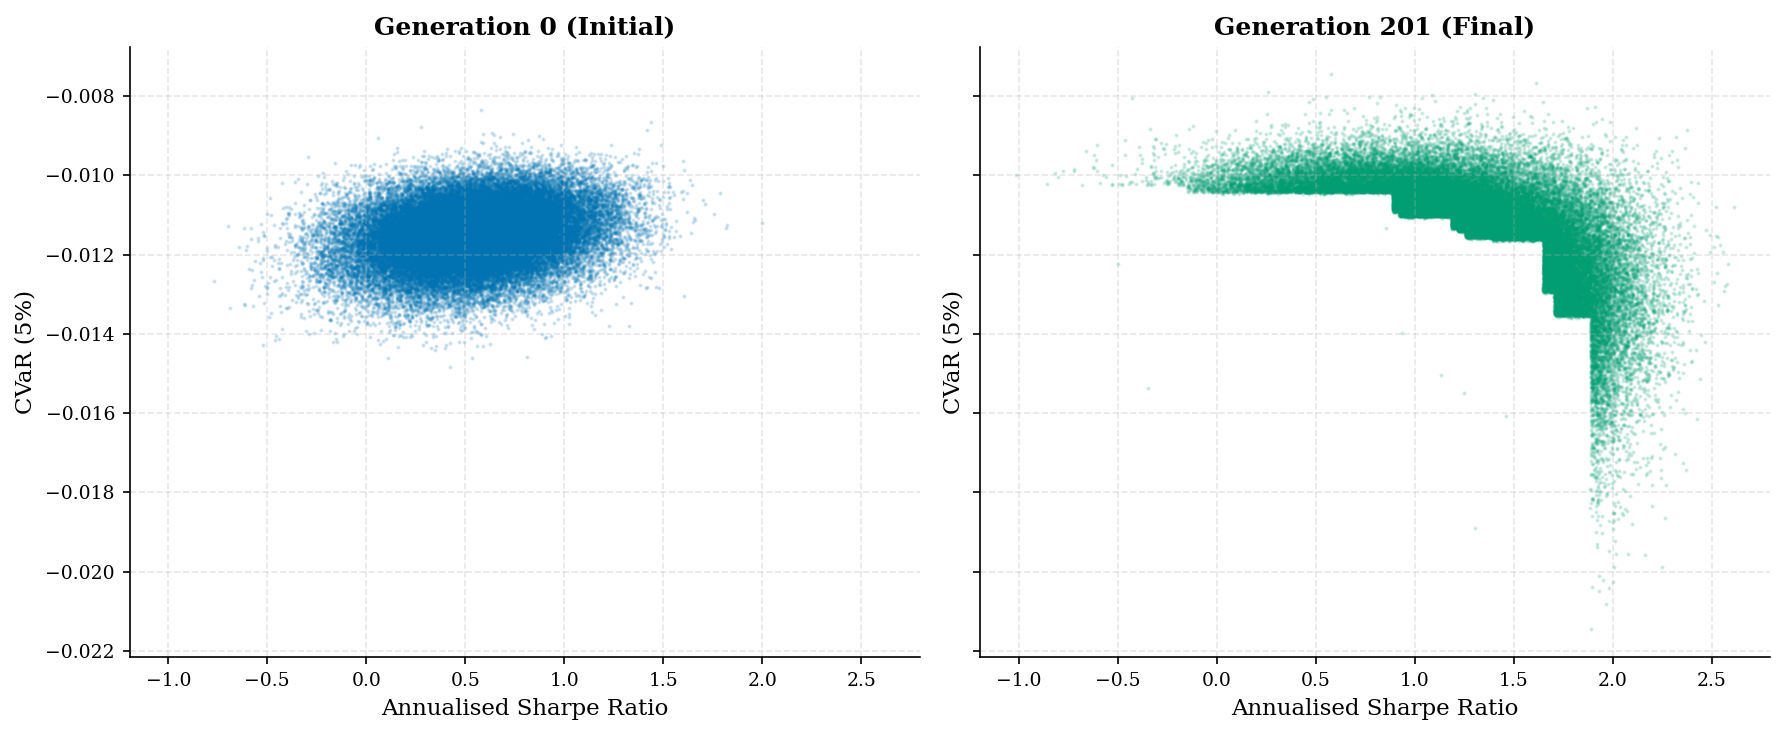

In [68]:
# --- Figure 7: Initial vs Final — side-by-side objective space -----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, (df_plot, title, c) in zip(axes, [
    (df_init, 'Generation 0 (Initial)', PALETTE[0]),
    (result.objectives, f'Generation {N_GENERATIONS} (Final)', PALETTE[2]),
]):
    clean = df_plot.replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(clean[obj_x], clean[obj_y],
               s=1, alpha=0.15, color=c, rasterized=True)
    ax.set_xlabel('Annualised Sharpe Ratio')
    ax.set_ylabel('CVaR (5%)')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/initial_vs_final.png', bbox_inches='tight')
plt.show()

## 8. Walk-Forward Backtest (No Look-Forward Data)

We run a walk-forward backtest where at each rebalance point the evolution only sees
**past returns**. The selected portfolio is then evaluated out-of-sample on the next
`step_size` days before rebalancing again.

- **Training window**: expanding (all history up to the rebalance date)
- **Rebalance frequency**: every 63 trading days (~quarterly)
- **Selection**: best Sharpe on the training frontier (default)

In [79]:
BT_POP_SIZE = 1_000
BT_GENERATIONS = 100
TRAIN_WINDOW = 400      # ~1 year of history before first trade
STEP_SIZE = 1           # ~quarterly rebalance

criterions = ["aggressive", "sharpe", "defensive"]
res_dict = {}

for criterion in criterions:
    print(f"Testing criterion: {criterion}")
    bt = Backtest(
        population_cls=LongOnlyBC,
        population_kwargs={'problem_dimension': n_assets, 'population_size': BT_POP_SIZE},
        list_loss=list_loss,
        domination_fn=epsilon.epsilon_dominant,
        domination_kwargs={'epsilon': 0.2},
        n_generations=BT_GENERATIONS,
        criterion=criterion
    )

    bt_result = bt.run(
        returns=returns,
        train_window=TRAIN_WINDOW,
        step_size=STEP_SIZE,
        expanding=False,
        verbose=True,
    )

    print(f'\nRebalance points: {len(bt_result.rebalance_points)}')
    print(f'OOS days:         {len(bt_result.portfolio_returns)}')
    print(f'Total return:     {bt_result.total_return:+.2%}')

    res_dict[criterion] = bt_result

Testing criterion: aggressive
Step   0  |  train [0:400]  |  OOS [400:401]  |  cumulative: -0.0073
Step   1  |  train [1:401]  |  OOS [401:402]  |  cumulative: -0.0013
Step   2  |  train [2:402]  |  OOS [402:403]  |  cumulative: -0.0070
Step   3  |  train [3:403]  |  OOS [403:404]  |  cumulative: -0.0062
Step   4  |  train [4:404]  |  OOS [404:405]  |  cumulative: -0.0034
Step   5  |  train [5:405]  |  OOS [405:406]  |  cumulative: -0.0039
Step   6  |  train [6:406]  |  OOS [406:407]  |  cumulative: -0.0111
Step   7  |  train [7:407]  |  OOS [407:408]  |  cumulative: -0.0160
Step   8  |  train [8:408]  |  OOS [408:409]  |  cumulative: -0.0047
Step   9  |  train [9:409]  |  OOS [409:410]  |  cumulative: -0.0041
Step  10  |  train [10:410]  |  OOS [410:411]  |  cumulative: +0.0087
Step  11  |  train [11:411]  |  OOS [411:412]  |  cumulative: -0.0062
Step  12  |  train [12:412]  |  OOS [412:413]  |  cumulative: +0.0003
Step  13  |  train [13:413]  |  OOS [413:414]  |  cumulative: -0.0049


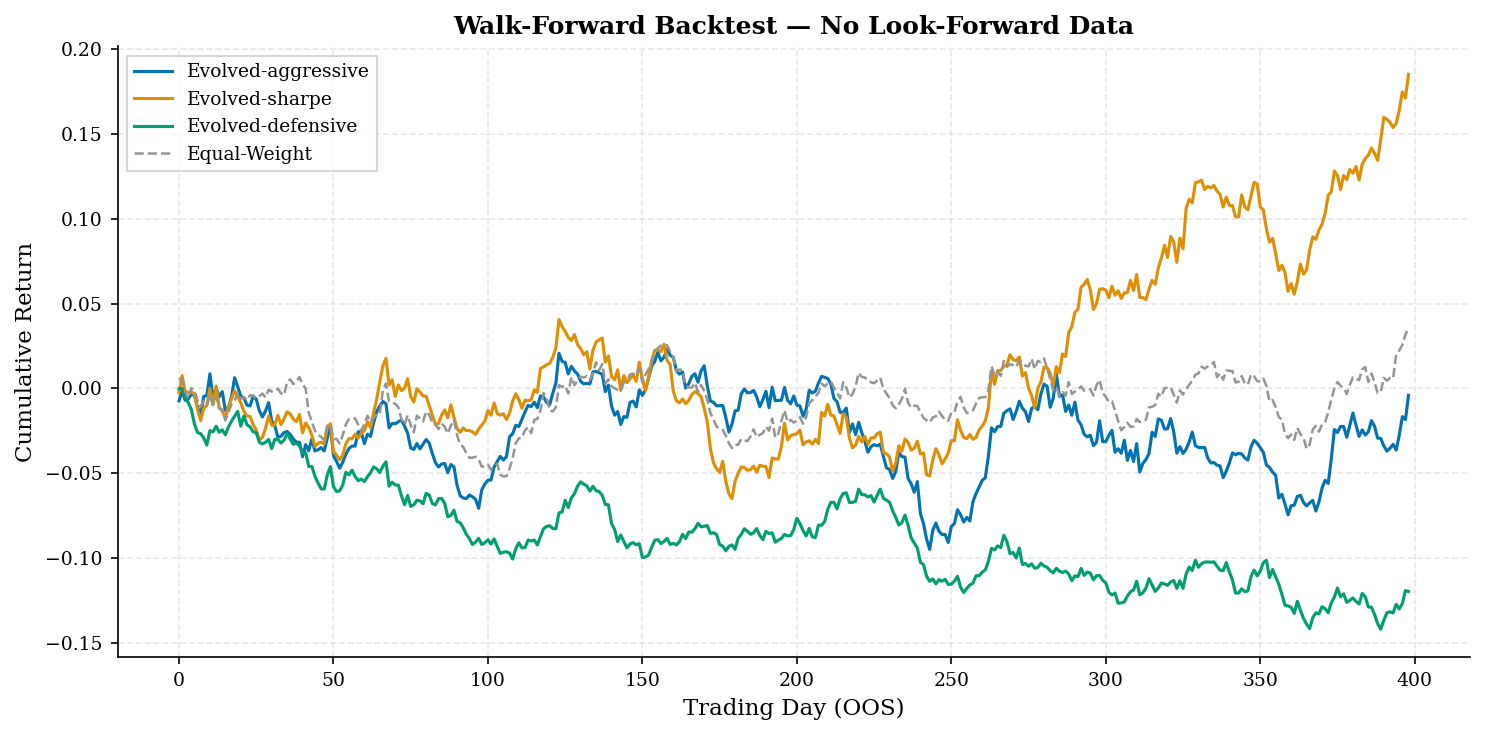

In [80]:
# --- Figure 8: Walk-forward equity curve ----------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

for k, criterion in enumerate(criterions):
    bt_result = res_dict[criterion]
    cum_ret = bt_result.cumulative_returns

    # Equal-weight benchmark over the same OOS period
    ew_weights = np.ones(n_assets) / n_assets
    oos_start = bt_result.rebalance_points[0]
    ew_returns = returns[oos_start:oos_start + len(cum_ret)] @ ew_weights
    ew_cum = np.cumprod(1 + ew_returns) - 1

    ax.plot(cum_ret, color=PALETTE[k], linewidth=1.5, label=f'Evolved-{criterion}')

    #for rp in bt_result.rebalance_points:
    #    ax.axvline(rp - oos_start, color='grey', alpha=0.15, linewidth=0.8)

    ax.set_xlabel('Trading Day (OOS)')
    ax.set_ylabel('Cumulative Return')
    ax.set_title('Walk-Forward Backtest — No Look-Forward Data', fontweight='bold')

ax.plot(ew_cum, color=PALETTE[7], linewidth=1.2, linestyle='--', label='Equal-Weight')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/backtest_equity.png', bbox_inches='tight')
plt.show()

## 9. Criterion Comparison

We compare the three selection criteria — **aggressive** (max mean return),
**sharpe** (max Sharpe ratio), and **defensive** (min variance) — across a battery
of out-of-sample performance metrics.

In [77]:
# --- Summary statistics table ---------------------------------------------
TRADING_DAYS = 252

rows = []
for criterion in criterions:
    bt_result = res_dict[criterion]
    r = bt_result.portfolio_returns

    total_ret = bt_result.total_return
    ann_ret = (1 + total_ret) ** (TRADING_DAYS / len(r)) - 1
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = np.cumprod(1 + r)
    running_max = np.maximum.accumulate(cum)
    drawdowns = cum / running_max - 1
    max_dd = drawdowns.min()
    # Sortino (downside vol)
    downside = r[r < 0]
    down_vol = downside.std() * np.sqrt(TRADING_DAYS) if len(downside) > 0 else np.nan
    sortino = ann_ret / down_vol if down_vol > 0 else np.nan
    # Calmar
    calmar = -ann_ret / max_dd if max_dd < 0 else np.nan
    # Win rate
    win_rate = (r > 0).mean()

    rows.append({
        'Criterion': criterion.capitalize(),
        'Total Return': f'{total_ret:+.1%}',
        'Ann. Return': f'{ann_ret:+.1%}',
        'Ann. Volatility': f'{ann_vol:.1%}',
        'Sharpe': f'{sharpe:.2f}',
        'Sortino': f'{sortino:.2f}',
        'Max Drawdown': f'{max_dd:.1%}',
        'Calmar': f'{calmar:.2f}',
        'Win Rate': f'{win_rate:.1%}',
    })

# Equal-weight benchmark
oos_start = res_dict[criterions[0]].rebalance_points[0]
n_oos = len(res_dict[criterions[0]].portfolio_returns)
ew_w = np.ones(n_assets) / n_assets
ew_r = returns[oos_start:oos_start + n_oos] @ ew_w
ew_total = float((1 + ew_r).prod() - 1)
ew_ann = (1 + ew_total) ** (TRADING_DAYS / len(ew_r)) - 1
ew_vol = ew_r.std() * np.sqrt(TRADING_DAYS)
ew_sharpe = ew_ann / ew_vol if ew_vol > 0 else np.nan
ew_cum = np.cumprod(1 + ew_r)
ew_rm = np.maximum.accumulate(ew_cum)
ew_dd = (ew_cum / ew_rm - 1).min()
ew_ds = ew_r[ew_r < 0]
ew_dv = ew_ds.std() * np.sqrt(TRADING_DAYS) if len(ew_ds) > 0 else np.nan
ew_sortino = ew_ann / ew_dv if ew_dv > 0 else np.nan
ew_calmar = -ew_ann / ew_dd if ew_dd < 0 else np.nan
ew_wr = (ew_r > 0).mean()

rows.append({
    'Criterion': 'Equal-Weight',
    'Total Return': f'{ew_total:+.1%}',
    'Ann. Return': f'{ew_ann:+.1%}',
    'Ann. Volatility': f'{ew_vol:.1%}',
    'Sharpe': f'{ew_sharpe:.2f}',
    'Sortino': f'{ew_sortino:.2f}',
    'Max Drawdown': f'{ew_dd:.1%}',
    'Calmar': f'{ew_calmar:.2f}',
    'Win Rate': f'{ew_wr:.1%}',
})

summary_df = pd.DataFrame(rows).set_index('Criterion')
summary_df

,Total Return,Ann. Return,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate
Criterion,,,,,,,,
Aggressive,+25.4%,+15.4%,9.6%,1.60,2.83,-5.0%,3.10,53.4%
Sharpe,+23.7%,+14.4%,9.6%,1.49,2.55,-9.4%,1.53,53.9%
Defensive,-2.8%,-1.8%,6.6%,-0.27,-0.45,-9.8%,-0.18,49.1%
Equal-Weight,+3.6%,+2.3%,7.1%,0.32,0.54,-6.0%,0.38,50.9%


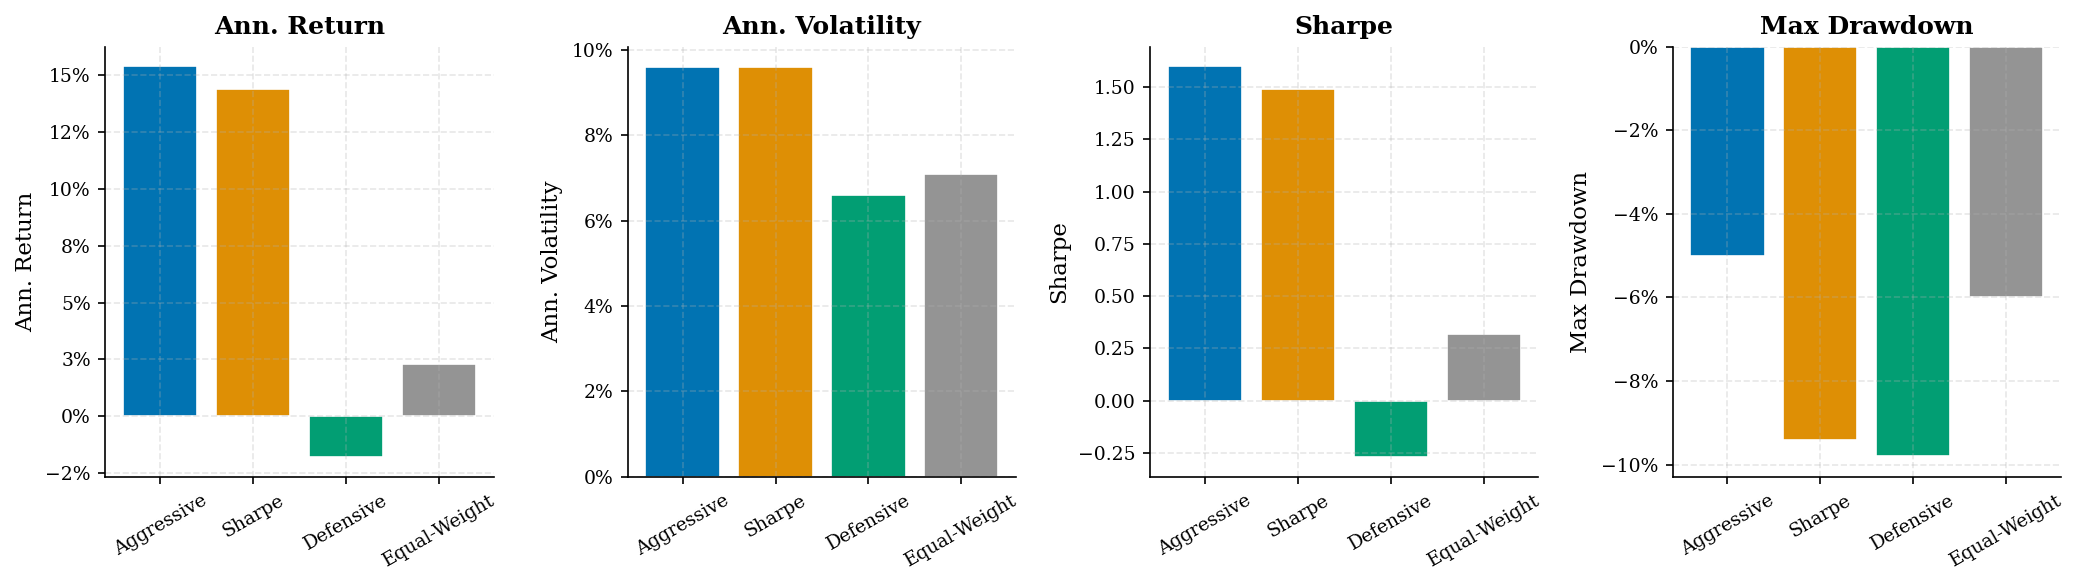

In [78]:
# --- Figure 9: Bar chart comparison of key metrics -----------------------
metrics = ['Ann. Return', 'Ann. Volatility', 'Sharpe', 'Max Drawdown']
fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))

colours = [PALETTE[k] for k in range(len(criterions))] + [PALETTE[7]]
labels = [c.capitalize() for c in criterions] + ['Equal-Weight']

for ax, metric in zip(axes, metrics):
    vals = [float(summary_df.loc[l, metric].strip('%+')) / 
            (100 if '%' in summary_df.loc[l, metric] else 1)
            for l in labels]
    bars = ax.bar(labels, vals, color=colours, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    # Format y-axis as percent where appropriate
    if '%' in summary_df.iloc[0][metric]:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_criterion_bars.png', bbox_inches='tight')
plt.show()

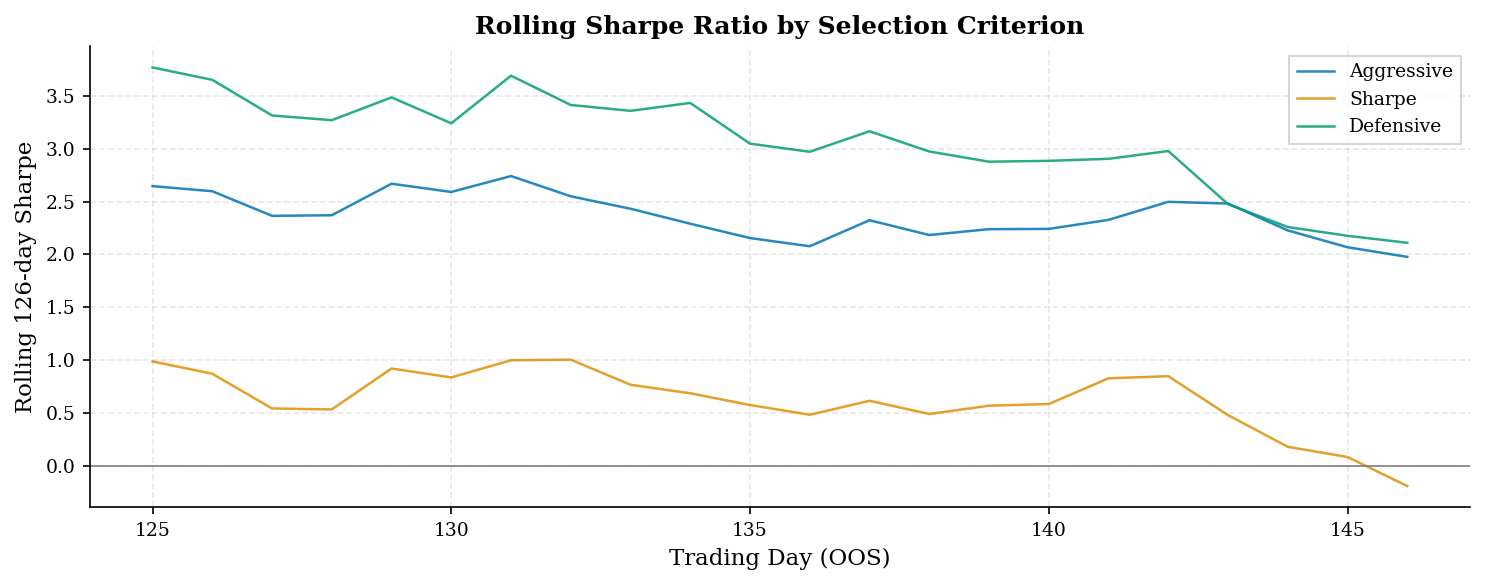

In [25]:
# --- Figure 10: Rolling Sharpe (126-day) per criterion --------------------
ROLL_WINDOW = 126

fig, ax = plt.subplots(figsize=(10, 4))

for k, criterion in enumerate(criterions):
    r = res_dict[criterion].portfolio_returns
    roll_mean = pd.Series(r).rolling(ROLL_WINDOW).mean()
    roll_std = pd.Series(r).rolling(ROLL_WINDOW).std()
    roll_sharpe = (roll_mean / roll_std) * np.sqrt(TRADING_DAYS)
    ax.plot(roll_sharpe, color=PALETTE[k], linewidth=1.2,
            label=criterion.capitalize(), alpha=0.85)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='-')
ax.set_xlabel('Trading Day (OOS)')
ax.set_ylabel(f'Rolling {ROLL_WINDOW}-day Sharpe')
ax.set_title('Rolling Sharpe Ratio by Selection Criterion', fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_rolling_sharpe.png', bbox_inches='tight')
plt.show()

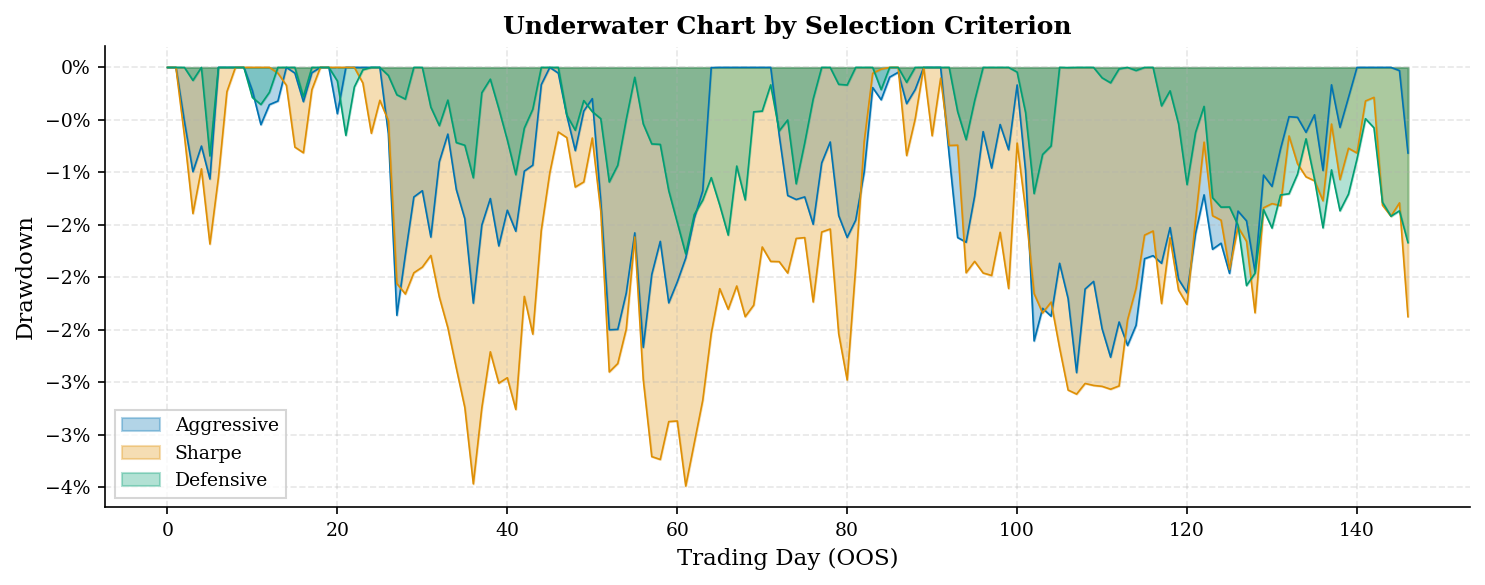

In [26]:
# --- Figure 11: Drawdown comparison ---------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

for k, criterion in enumerate(criterions):
    r = res_dict[criterion].portfolio_returns
    cum = np.cumprod(1 + r)
    running_max = np.maximum.accumulate(cum)
    dd = cum / running_max - 1
    ax.fill_between(range(len(dd)), dd, 0, color=PALETTE[k],
                    alpha=0.3, label=criterion.capitalize())
    ax.plot(dd, color=PALETTE[k], linewidth=0.8)

ax.set_xlabel('Trading Day (OOS)')
ax.set_ylabel('Drawdown')
ax.set_title('Underwater Chart by Selection Criterion', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_drawdowns.png', bbox_inches='tight')
plt.show()

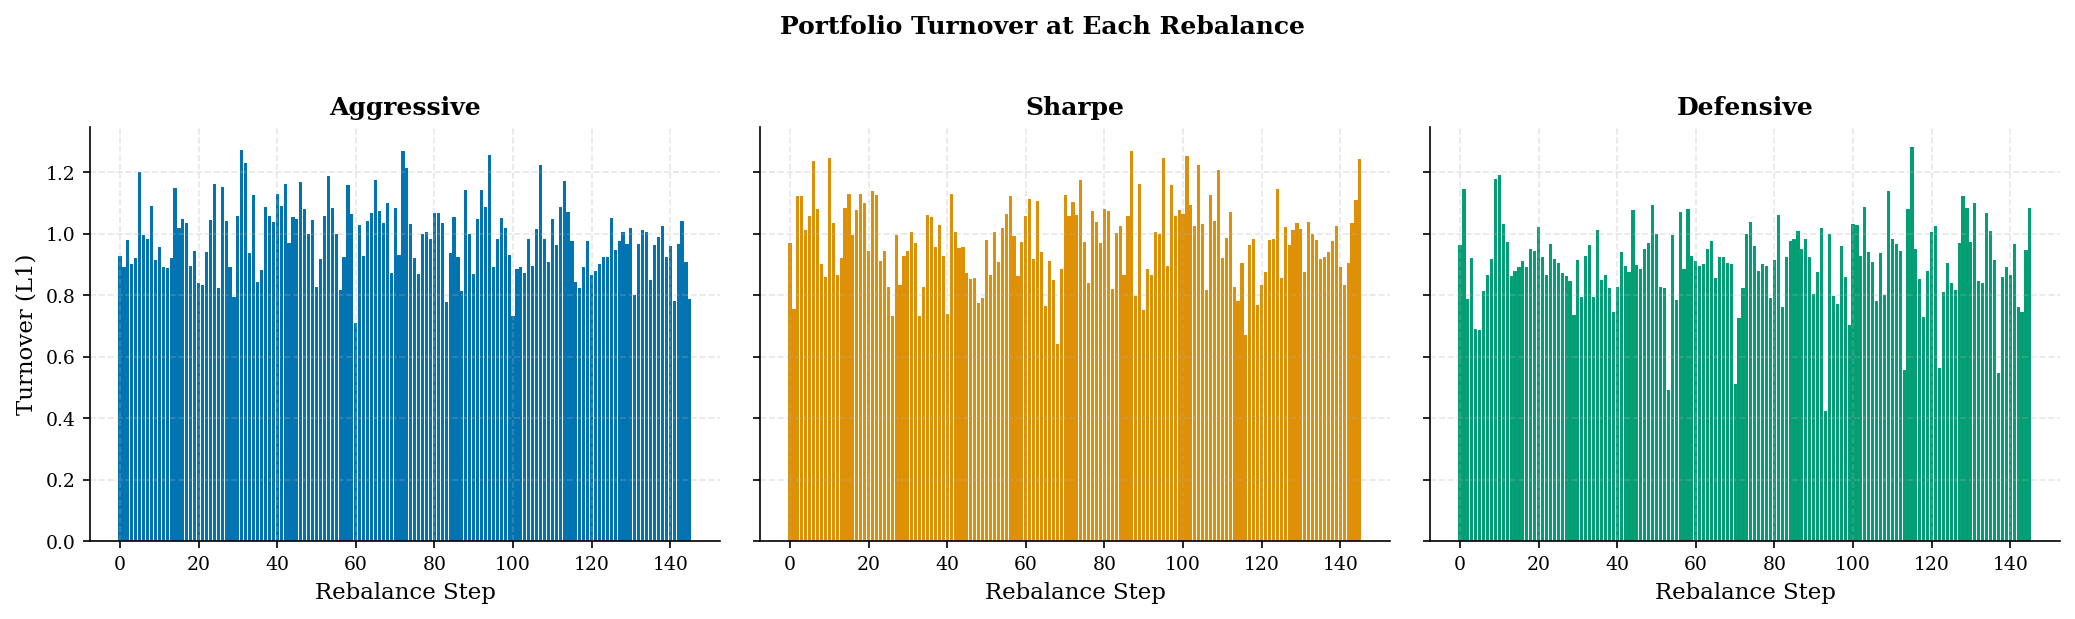

In [28]:
# --- Figure 12: Weight turnover per criterion -----------------------------
fig, axes = plt.subplots(1, len(criterions), figsize=(14, 4),
                         sharey=True)

for k, criterion in enumerate(criterions):
    weights = np.array(res_dict[criterion].chosen_weights)
    # Turnover = L1 norm of weight changes between rebalances
    turnover = np.abs(np.diff(weights, axis=0)).sum(axis=1)

    ax = axes[k]
    ax.bar(range(len(turnover)), turnover, color=PALETTE[k],
           edgecolor='white', linewidth=0.01)
    ax.set_xlabel('Rebalance Step')
    ax.set_title(f'{criterion.capitalize()}', fontweight='bold')
    if k == 0:
        ax.set_ylabel('Turnover (L1)')

fig.suptitle('Portfolio Turnover at Each Rebalance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_turnover.png', bbox_inches='tight')
plt.show()